# Exploratory Data Analysis (EDA)

## Objective
This notebook explores the cleaned African development dataset to understand:

- Internet penetration trends
- Education enrollment patterns
- GDP growth characteristics
- Country-level differences
- Temporal trends from 2000–2024

The goal is to identify patterns, anomalies, and relationships before performing statistical analysis.

In [1]:
#Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

In [2]:
#loading the dataset

df = pd.read_csv(r"D:\GIT\data-analytics-portfolio\01-world-bank-analysis\data\cleaned_data\africa_data_cleaned.csv")

df.head()

,Country,Country_Code,Year,GDP_Growth,Internet_Usage,Secondary_Enrollment
0,Algeria,DZA,2000,0.491706,3.8,64.595421
1,Algeria,DZA,2001,0.646114,3.0,68.763298
2,Algeria,DZA,2002,1.591641,5.4,72.583069
3,Algeria,DZA,2003,2.195360,6.5,75.435867
4,Algeria,DZA,2004,4.634475,4.5,79.629860


In [3]:
df.columns

Index(['Country', 'Country_Code', 'Year', 'GDP_Growth', 'Internet_Usage',
       'Secondary_Enrollment'],
      dtype='str')

In [4]:

print(df.info())

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               1134 non-null   str    
 1   Country_Code          1134 non-null   str    
 2   Year                  1134 non-null   int64  
 3   GDP_Growth            1134 non-null   float64
 4   Internet_Usage        1134 non-null   float64
 5   Secondary_Enrollment  1109 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 53.3 KB
None


(1134, 6)

In [5]:
#missing values in the dataset

df.isnull().sum()

Country                  0
Country_Code             0
Year                     0
GDP_Growth               0
Internet_Usage           0
Secondary_Enrollment    25
dtype: int64

In [6]:
(
    df.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

Secondary_Enrollment    2.204586
Country                 0.000000
Country_Code            0.000000
Year                    0.000000
GDP_Growth              0.000000
Internet_Usage          0.000000
dtype: float64

### Findings

- The dataset contains observations for African countries between 2000 and 2024.

- Secondary enrollment contains some missing records that should be noted in later analysis.

In [7]:
#descriptive statistics

df.describe()

,Year,GDP_Growth,Internet_Usage,Secondary_Enrollment
count,1134.000000,1134.000000,1134.000000,1109.000000
mean,2012.001764,16.537988,3.963021,47.354030
std,7.182650,20.566617,6.483826,24.998719
min,2000.000000,0.015264,-50.338515,5.940960
25%,2006.000000,1.633685,2.161904,29.422052
50%,2012.000000,7.240768,4.310545,41.556252
75%,2018.000000,23.795000,6.238107,63.075798
max,2024.000000,91.200000,86.826748,122.120628


In [8]:
df[['GDP_Growth',
    'Internet_Usage',
    'Secondary_Enrollment']].agg(
    ['mean','median','min','max','std']
)

,GDP_Growth,Internet_Usage,Secondary_Enrollment
mean,16.537988,3.963021,47.354030
median,7.240768,4.310545,41.556252
min,0.015264,-50.338515,5.940960
max,91.200000,86.826748,122.120628
std,20.566617,6.483826,24.998719


### Summary Insights

- Internet usage varies widely across countries.
- GDP growth contains substantial variation and several negative values.
- Secondary enrollment generally exceeds internet usage levels.

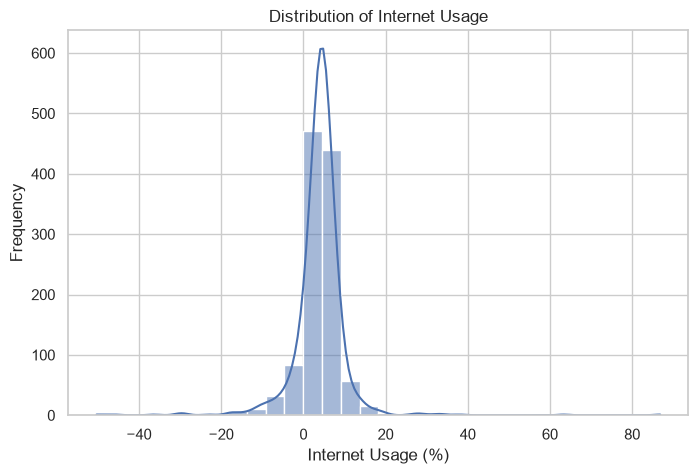

In [9]:
#Distribution of internet usage in Africa

plt.figure(figsize=(8,5))

sns.histplot(
    df['Internet_Usage'],
    bins=30,
    kde=True
)

plt.title('Distribution of Internet Usage')
plt.xlabel('Internet Usage (%)')
plt.ylabel('Frequency')
plt.show()

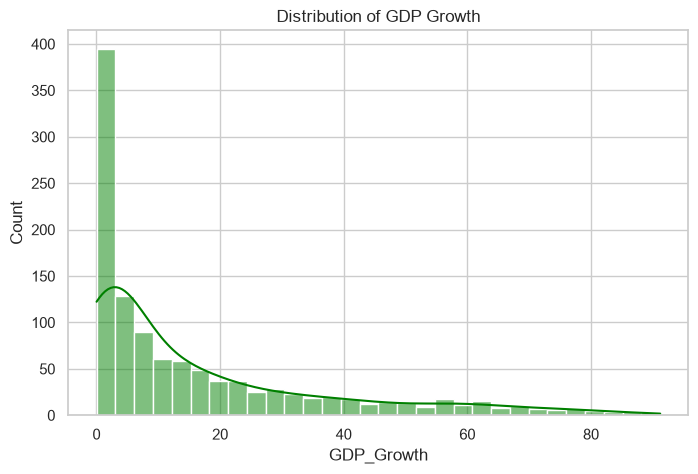

In [10]:
#GDP growth in Africa

plt.figure(figsize=(8,5))

sns.histplot(
    df['GDP_Growth'],
    bins=30,
    kde=True,
    color='green'
)

plt.title('Distribution of GDP Growth')
plt.show() 

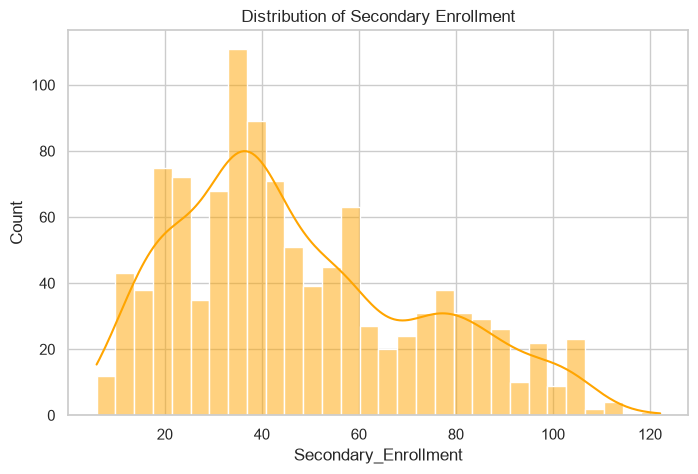

In [11]:
#Secondary Enrollment Distribution 

plt.figure(figsize=(8,5))

sns.histplot(
    df['Secondary_Enrollment'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title('Distribution of Secondary Enrollment')
plt.show()

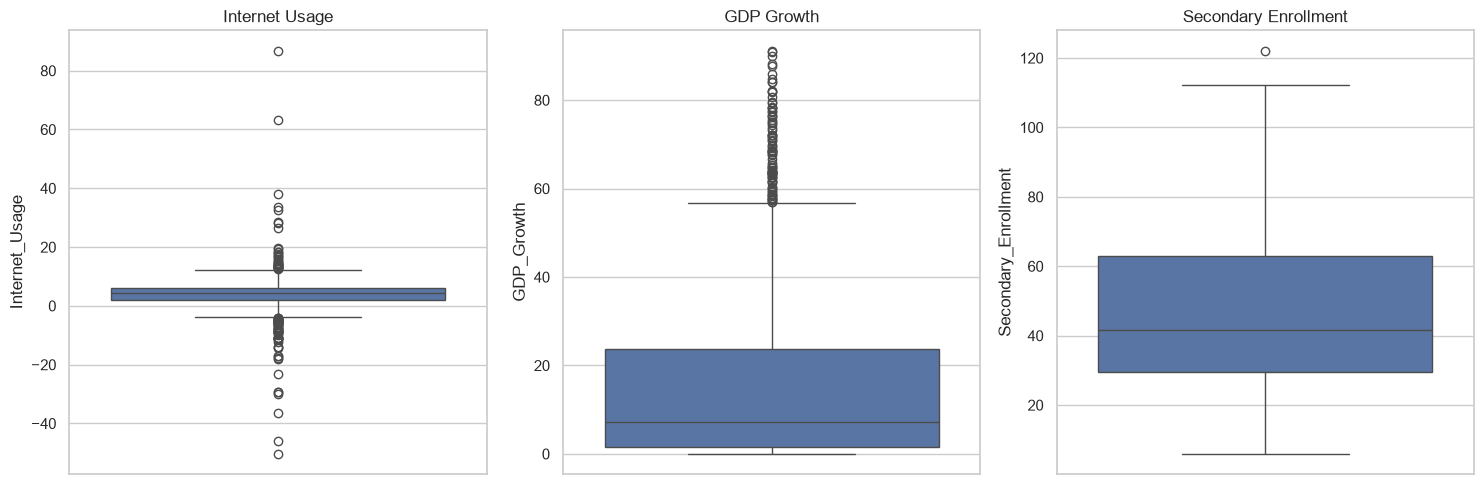

In [12]:
#Outlier detection using boxplots

fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(y=df['Internet_Usage'], ax=axes[0])
axes[0].set_title("Internet Usage")

sns.boxplot(y=df['GDP_Growth'], ax=axes[1])
axes[1].set_title("GDP Growth")

sns.boxplot(y=df['Secondary_Enrollment'], ax=axes[2])
axes[2].set_title("Secondary Enrollment")

plt.tight_layout()
plt.show()

### Outlier Analysis

- Some countries exhibit unusually high internet penetration.
- GDP growth contains extreme positive and negative observations.
- Enrollment values above 100% appear due to gross enrollment calculations.

In [13]:
#Country comparisons internet usage

internet_rank = (
    df.groupby('Country')['Internet_Usage']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

internet_rank

Country
Ethiopia             8.400714
Rwanda               7.420173
Equatorial Guinea    6.841387
Djibouti             6.506735
Tanzania             5.925990
Uganda               5.890003
Mozambique           5.807247
Chad                 5.763357
Ghana                5.590528
Zambia               5.397018
Name: Internet_Usage, dtype: float64

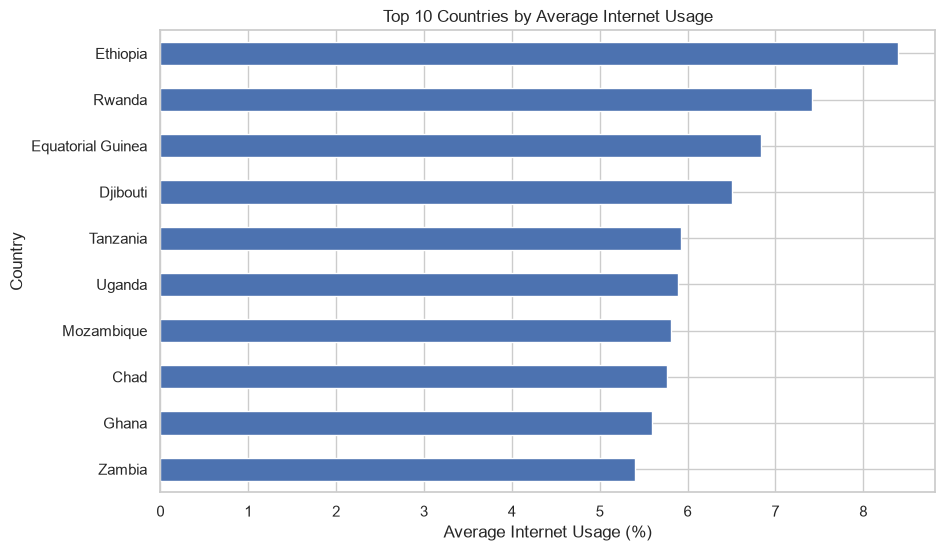

In [14]:
plt.figure(figsize=(10,6))

internet_rank.sort_values().plot(kind='barh')

plt.title("Top 10 Countries by Average Internet Usage")
plt.xlabel("Average Internet Usage (%)")
plt.show()

In [15]:
# Country comparisons Education Enrollment

education_rank = (
    df.groupby('Country')['Secondary_Enrollment']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

education_rank

Country
Libya           99.480050
Algeria         93.202522
South Africa    92.154263
Mauritius       88.745287
Tunisia         86.216089
Seychelles      86.187218
Botswana        75.080944
Namibia         72.809906
Eswatini        66.663928
Morocco         65.691262
Name: Secondary_Enrollment, dtype: float64

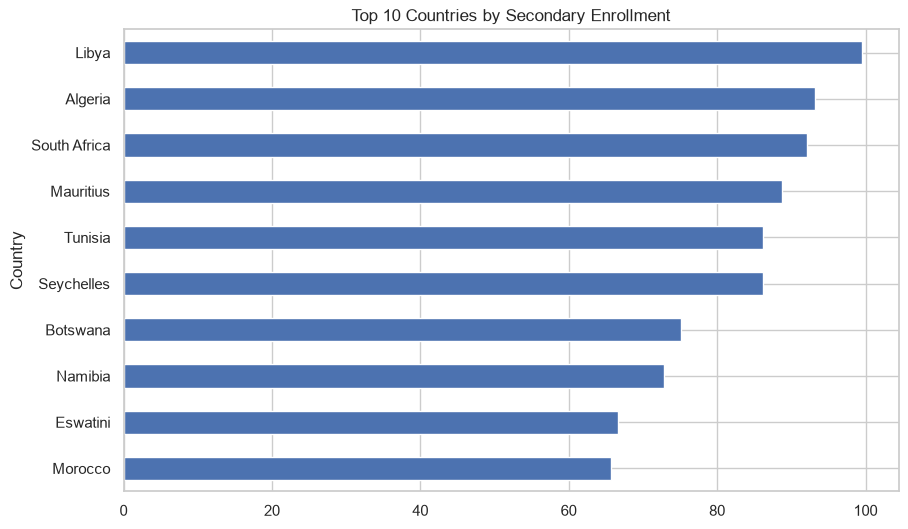

In [16]:
plt.figure(figsize=(10,6))

education_rank.sort_values().plot(kind='barh')

plt.title("Top 10 Countries by Secondary Enrollment")
plt.show()

In [17]:
# Country comparisons GDP Growth

gdp_rank = (
    df.groupby('Country')['GDP_Growth']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

gdp_rank

Country
Seychelles      48.939112
Morocco         47.473678
Mauritius       39.116975
Tunisia         39.065710
South Africa    37.846067
Gabon           30.462265
Algeria         29.959526
Libya           29.690146
Botswana        25.494067
Djibouti        24.209026
Name: GDP_Growth, dtype: float64

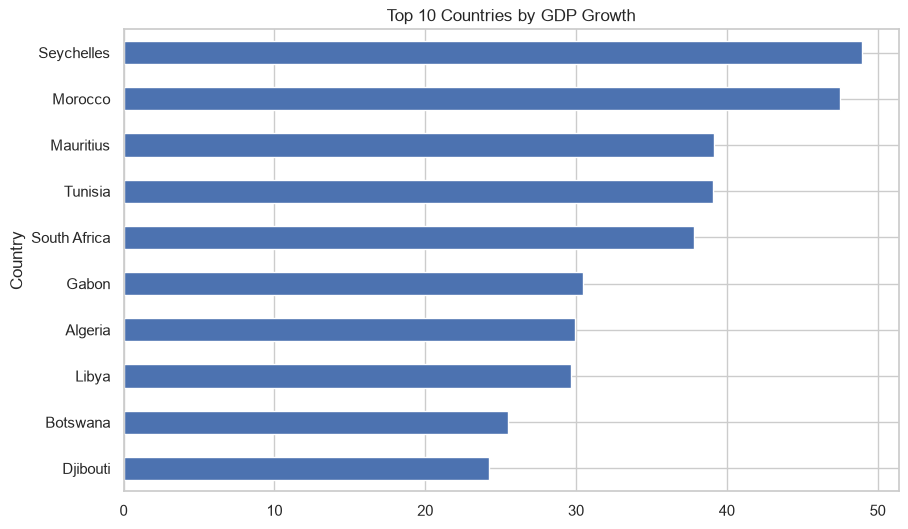

In [18]:
plt.figure(figsize=(10,6))

gdp_rank.sort_values().plot(kind='barh')

plt.title("Top 10 Countries by GDP Growth")
plt.show()

## Trend Analysis


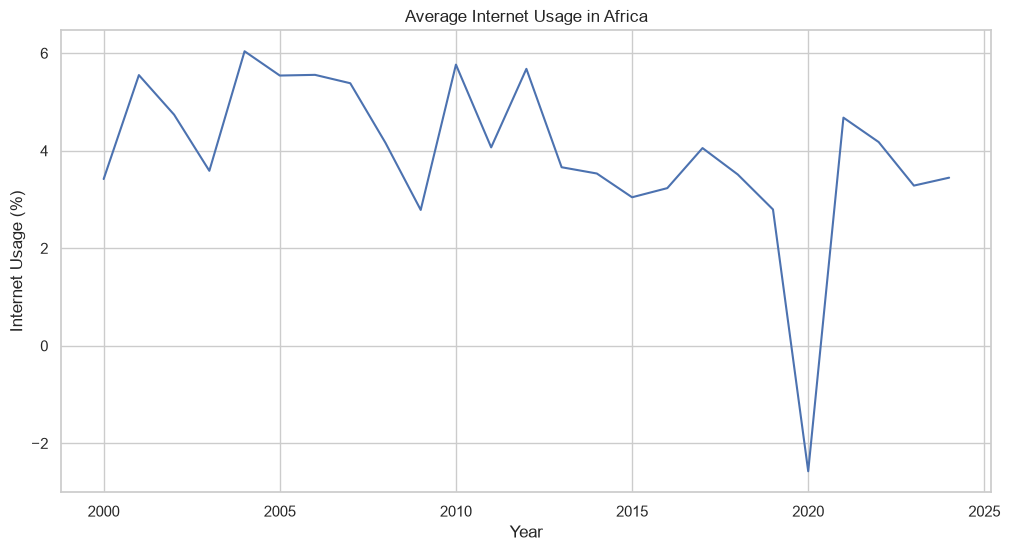

In [21]:
#Average Internet Usage over the years

yearly_internet = (
    df.groupby('Year')['Internet_Usage']
      .mean()
)

plt.figure(figsize=(12,6))

yearly_internet.plot()

plt.title('Average Internet Usage in Africa')
plt.ylabel('Internet Usage (%)')
plt.show()

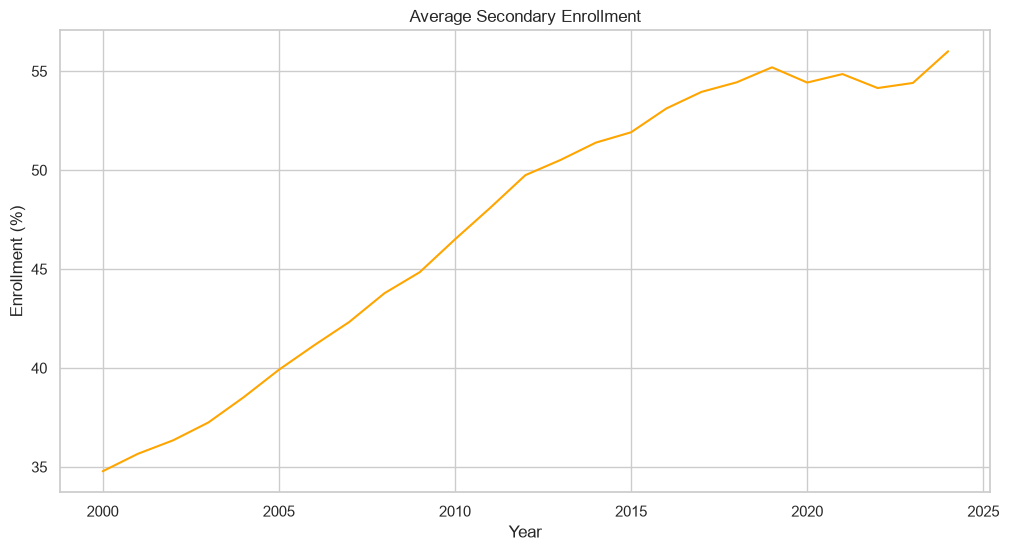

In [20]:
#Average secondary enrollment in Africa over the years

yearly_edu = (
    df.groupby('Year')['Secondary_Enrollment']
      .mean()
)

plt.figure(figsize=(12,6))

yearly_edu.plot(color='orange')

plt.title('Average Secondary Enrollment')
plt.ylabel('Enrollment (%)')
plt.show()

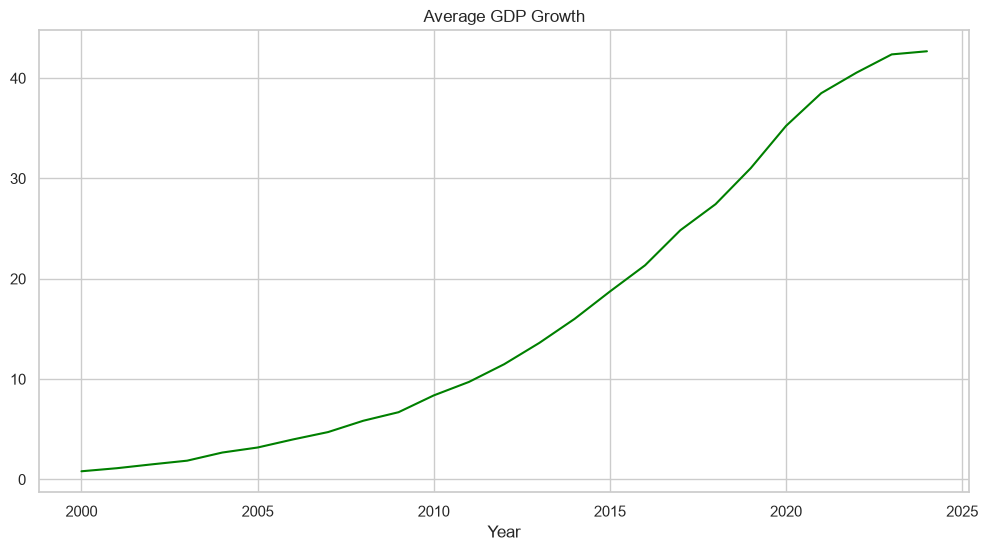

In [22]:
#Average GDP Growth in Africa over the years

yearly_gdp = (
    df.groupby('Year')['GDP_Growth']
      .mean()
)

plt.figure(figsize=(12,6))

yearly_gdp.plot(color='green')

plt.title('Average GDP Growth')
plt.show()

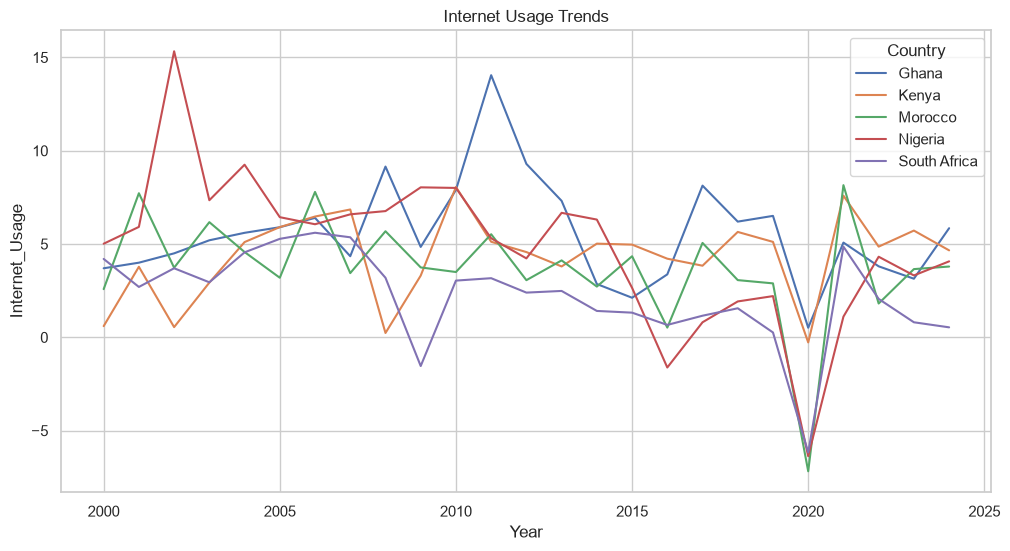

In [23]:
#comparing selected countries based on internet usage, secondary enrollment and GDP growth

countries = [
    'Kenya',
    'South Africa',
    'Nigeria',
    'Morocco',
    'Ghana'
]

subset = df[df['Country'].isin(countries)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=subset,
    x='Year',
    y='Internet_Usage',
    hue='Country'
)

plt.title('Internet Usage Trends')
plt.show()

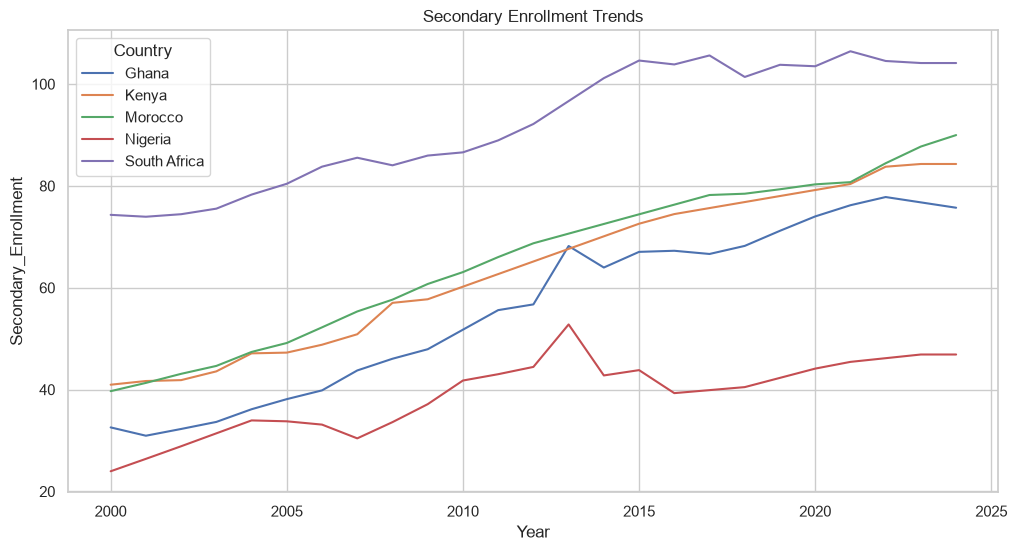

In [24]:
countries = [
    'Kenya',
    'South Africa',
    'Nigeria',
    'Morocco',
    'Ghana'
]

subset = df[df['Country'].isin(countries)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=subset,
    x='Year',
    y='Secondary_Enrollment',
    hue='Country'
)

plt.title('Secondary Enrollment Trends')
plt.show()

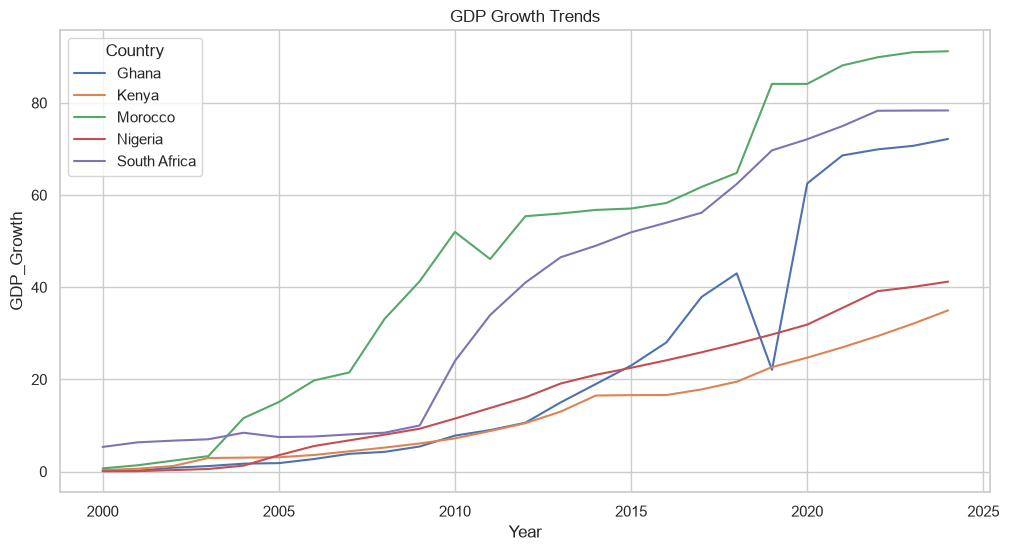

In [25]:
countries = [
    'Kenya',
    'South Africa',
    'Nigeria',
    'Morocco',
    'Ghana'
]

subset = df[df['Country'].isin(countries)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=subset,
    x='Year',
    y='GDP_Growth',
    hue='Country'
)

plt.title('GDP Growth Trends')
plt.show()

# Key Findings

## Internet Usage
- Internet adoption increased substantially across Africa.
- Significant disparities exist between countries.

## Education
- Secondary enrollment improved in many countries.
- Some countries consistently outperform regional averages.

## GDP Growth
- Economic growth varies considerably over time and across countries.
- Major external shocks are visible in the data.

## Next Steps
The next notebook will investigate the statistical relationships among Internet Usage, Secondary Enrollment, and GDP Growth using correlation and regression analysis.